In [1]:
print(__doc__)
import numpy as np
np.random.seed(123)

import matplotlib.pyplot as plt


Automatically created module for IPython interactive environment


In [2]:
from skopt.benchmarks import branin as branin
from skopt.benchmarks import hart6 as hart6_


# redefined `hart6` to allow adding arbitrary "noise" dimensions
def hart6(x):
    return hart6_(x[:6])

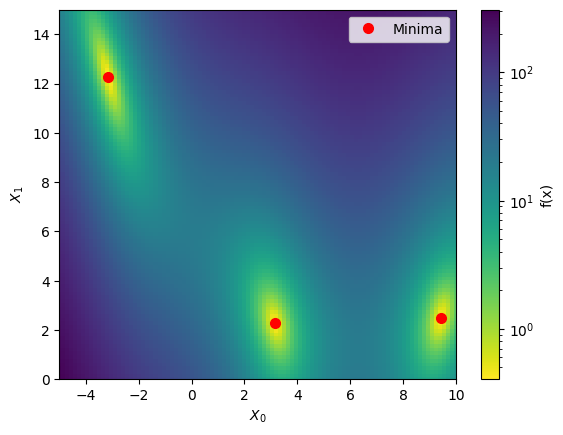

In [3]:
from matplotlib.colors import LogNorm

def plot_branin():
    fig, ax = plt.subplots()

    x1_values = np.linspace(-5, 10, 100)
    x2_values = np.linspace(0, 15, 100)
    x_ax, y_ax = np.meshgrid(x1_values, x2_values)
    vals = np.c_[x_ax.ravel(), y_ax.ravel()]
    fx = np.reshape([branin(val) for val in vals], (100, 100))

    cm = ax.pcolormesh(x_ax, y_ax, fx,
                       norm=LogNorm(vmin=fx.min(),
                                    vmax=fx.max()),
                       cmap='viridis_r')

    minima = np.array([[-np.pi, 12.275], [+np.pi, 2.275], [9.42478, 2.475]])
    ax.plot(minima[:, 0], minima[:, 1], "r.", markersize=14,
            lw=0, label="Minima")

    cb = fig.colorbar(cm)
    cb.set_label("f(x)")

    ax.legend(loc="best", numpoints=1)

    ax.set_xlabel("$X_0$")
    ax.set_xlim([-5, 10])
    ax.set_ylabel("$X_1$")
    ax.set_ylim([0, 15])


plot_branin()

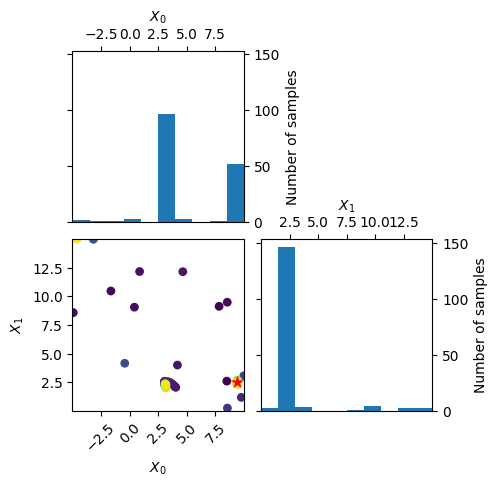

In [12]:
from skopt.benchmarks import branin
from skopt import gp_minimize
#from skopt.space import Real
#from functools import partial
from skopt.plots import plot_evaluations

bounds = [(-5.0, 10.0), (0.0, 15.0)]
n_calls = 160

gp_res = gp_minimize(branin, bounds, n_calls=n_calls, random_state=4)

_ = plot_evaluations(gp_res, bins=10)




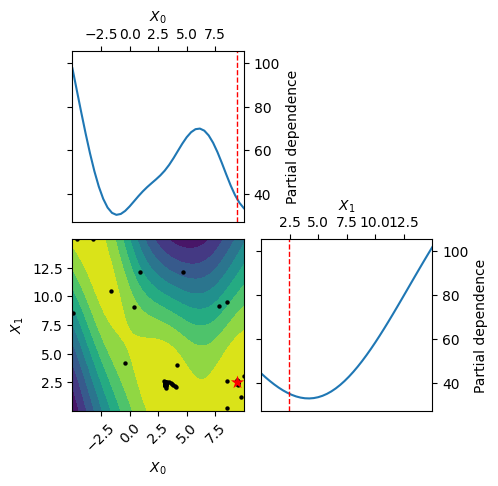

In [10]:
from skopt.plots import plot_objective

_ = plot_objective(forest_res)

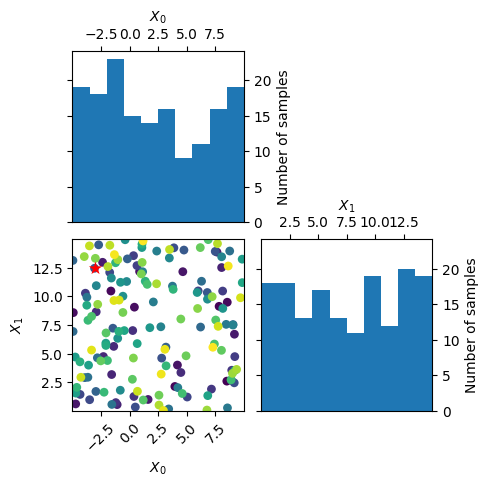

In [11]:
dummy_res = dummy_minimize(branin, bounds, n_calls=n_calls, random_state=4)

_ = plot_evaluations(dummy_res, bins=10)